# TSMC: PyTorch LSTM forecasting experiment

**Prepared for your run; no cells have been executed.** Run from top to bottom in a Python kernel with PyTorch, NumPy, pandas, scikit-learn, Matplotlib, joblib, and IPython installed. This notebook does not install packages or start background workers.

Predict the **next observed trading day's unadjusted closing price in USD**, using information available after the current day's close. Compare three feature sets, two lookbacks, two LSTM hidden sizes, and one/two stacked recurrent layers. The 70/15/15 target-date boundaries and price metrics follow the existing ARIMA/SARIMA experiments. Trading strategy and profitability are deferred.

**Architecture:** today's known close + a learned LSTM correction. The network is trained against the next-day price, not a return-classification label. The explicit persistence connection avoids making a small network reconstruct the entire trending price level; it does not guarantee an improvement over persistence. This architectural choice is fixed for all configurations and must be disclosed in the report.

**Resource budget:** 24 screening fits; at most four additional fits to repeat the top two configurations over three seeds; one final refit. Fits are sequential. Each tuning fit has at most 40 epochs, early stopping, and a 90-second training budget checked after each epoch. This is a soft time limit: an epoch and prediction/checkpoint overhead can exceed it. Input windows are sliced on demand instead of copying a large 3D dataset. CPU execution uses at most two intra-operation threads and no DataLoader workers. A compatible CUDA GPU is used if available; set `DEVICE_PREFERENCE='cpu'` to force CPU. Runtime is hardware-dependent, and no speed guarantee is implied.

**Evidence and limitations:** the master file is built from local Yahoo Finance data with Google comparisons; `Adj Close` is excluded because historical point-in-time adjustment provenance is unavailable. The existing project has already inspected part of the historical test period. The final test here is held out from this procedure, but not a completely untouched research sample. High R² or low price error does not establish profitability.

API references: [PyTorch LSTM](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html), [saving and loading state dictionaries](https://docs.pytorch.org/tutorials/beginner/basics/saveloadrun_tutorial.html), [reproducibility](https://docs.pytorch.org/docs/stable/notes/randomness.html).


## 1. Configuration and resource limits

`hidden_size` is the number of units in each LSTM layer; `num_layers` is the number of stacked LSTM layers. Both vary independently. Each feature set receives the same eight architecture/window combinations. Learning rate, batch size, dropout, and optimizer are fixed to keep the search affordable; they are recorded, not claimed to be optimal.

The first seed screens all configurations. The top two are compared using the mean validation RMSE over three fixed seeds; the screening fit is reused, so only four new fits are needed. The final seed is fixed in advance rather than chosen for a lucky score. The final epoch count comes from internal-stopping histories, never from test results.

Reproducible seeds and deterministic settings reduce run-to-run variation. Identical results across PyTorch versions, operating systems, CPUs, and GPUs are not guaranteed. Keep the manifest for your report.


In [1]:
from pathlib import Path
import os
import gc
import json
import time
import random
import hashlib
import platform
from itertools import product
from datetime import datetime, timezone

CPU_THREADS = min(2, os.cpu_count() or 1)
for key in ['OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS']:
    os.environ[key] = str(CPU_THREADS)
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

try:
    import torch
except ImportError as exc:
    raise ImportError('PyTorch is missing in this kernel. Install the appropriate build from pytorch.org/get-started/locally and restart the kernel.') from exc
from torch import nn
from torch.utils.data import Dataset, DataLoader
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display, Markdown

torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass  # A reused kernel may already have initialized the interop pool.
torch.use_deterministic_algorithms(True, warn_only=True)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

DEVICE_PREFERENCE = 'auto'  # 'auto' or 'cpu'; fits are never parallelized.
assert DEVICE_PREFERENCE in {'auto', 'cpu'}
DEVICE = torch.device('cuda' if DEVICE_PREFERENCE == 'auto' and torch.cuda.is_available() else 'cpu')
TRAIN_FRACTION, VALIDATION_FRACTION = 0.70, 0.15
STOPPING_FRACTION = 0.15  # Last 15% of eligible training windows, not external validation.
LOOKBACKS = [20, 60]
HIDDEN_SIZES = [32, 64]
LAYER_COUNTS = [1, 2]
DROPOUT = 0.10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 64
MAX_EPOCHS = 40
PATIENCE = 6
MIN_DELTA = 1e-6  # Scaled-price MSE units, used for the patience counter.
MAX_TRIAL_SECONDS = 90.0
GRADIENT_CLIP = 1.0
SEEDS = [42, 123, 2026]
FINAL_SEED = 42
TOP_K = 2

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'Data' / 'TSMC_Master_Features_15Y.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Start Jupyter in the project containing Data/TSMC_Master_Features_15Y.csv.')
DATA_FILE = ROOT / 'Data' / 'TSMC_Master_Features_15Y.csv'
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
RUN_DIR = ROOT / 'models' / 'lstm' / RUN_ID
PLOT_DIR = RUN_DIR / 'plots'
TRIAL_DIR = RUN_DIR / 'trials'
PLOT_DIR.mkdir(parents=True, exist_ok=False)
TRIAL_DIR.mkdir()
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def finish_plot(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def release_memory():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

print('Device:', DEVICE, '| CPU threads:', torch.get_num_threads())
print('PyTorch:', torch.__version__)
print('Artifacts:', RUN_DIR)


Device: cuda | CPU threads: 2
PyTorch: 2.11.0+cu128
Artifacts: f:\SEM-7\Time Series Analysis\Project\models\lstm\20260923T041634383000Z


## 2. Audit the master data

Check dates, positive prices, finite numeric values, and OHLC consistency. Recompute the master indicators from historical lags and trailing windows. This checks the local feature calculations; it is not independent vendor verification. Missing leading indicator values are expected and will define the common window warm-up. Never backfill them from the future.


In [2]:
raw = pd.read_csv(DATA_FILE)
raw['Date'] = pd.to_datetime(raw['Date'], errors='raise')
raw = raw.sort_values('Date').reset_index(drop=True)
assert raw['Date'].notna().all() and raw['Date'].is_unique, 'Missing or duplicate dates.'
assert raw['Date'].is_monotonic_increasing
numeric_columns = raw.columns.drop('Date').tolist()
raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors='raise')
assert not np.isinf(raw[numeric_columns].to_numpy()).any(), 'Infinite data values.'
assert (raw['Close'] > 0).all() and (raw['Volume'] >= 0).all()
tol = 1e-5
assert (raw['High'] + tol >= raw[['Open', 'Close', 'Low']].max(axis=1)).all()
assert (raw['Low'] - tol <= raw[['Open', 'Close', 'High']].min(axis=1)).all()

expected = {
    'Log_Close': np.log(raw['Close']),
    'Return_1D': raw['Close'].pct_change(fill_method=None),
    'Log_Return_1D': np.log(raw['Close']).diff(),
    'High_Low_Range': (raw['High'] - raw['Low']) / raw['Close'],
    'Open_Close_Change': (raw['Close'] - raw['Open']) / raw['Open'],
    'Day_of_Week': raw['Date'].dt.dayofweek,
    'Month': raw['Date'].dt.month, 'Quarter': raw['Date'].dt.quarter,
    'Year': raw['Date'].dt.year,
}
for lag in [1, 2, 3, 5, 10, 20]:
    expected[f'Close_Lag_{lag}'] = raw['Close'].shift(lag)
    expected[f'Return_Lag_{lag}'] = expected['Return_1D'].shift(lag)
for window in [5, 10, 20, 50]:
    expected[f'SMA_{window}'] = raw['Close'].rolling(window).mean()
for window in [5, 10, 20]:
    expected[f'Volatility_{window}'] = expected['Log_Return_1D'].rolling(window).std()
    expected[f'Momentum_{window}D'] = raw['Close'].pct_change(window, fill_method=None)
for name, values in expected.items():
    np.testing.assert_allclose(raw[name], values, rtol=1e-6, atol=1e-8,
                               equal_nan=True, err_msg=f'Feature mismatch: {name}')

audit = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum()})
display(audit)
print(f'{len(raw):,} rows; {len(raw.columns)} columns; '
      f"{raw['Date'].min().date()} through {raw['Date'].max().date()}")
print('Verified all engineered columns against causal trailing calculations.')
audit.to_csv(RUN_DIR / 'data_audit.csv')


,dtype,missing
Date,datetime64[ns],0
Open,float64,0
High,float64,0
Low,float64,0
Close,float64,0
Adj Close,float64,0
Volume,int64,0
Log_Close,float64,0
Return_1D,float64,1
Log_Return_1D,float64,1


3,771 rows; 38 columns; 2011-09-12 through 2026-09-10
Verified all engineered columns against causal trailing calculations.


## 3. Feature sets, target dates, and identical external splits

| Feature set | Purpose |
|---|---|
| `close_only` | Does sequential closing-price history help? |
| `ohlcv` | Do daily prices and volume add useful information? |
| `all_features` | Do all causally available engineered features improve forecasts? |

The third set retains every original numeric feature except `Adj Close`; raw calendar columns remain ordinal numeric inputs, a documented simplification. These sets are experiments, not assertions that particular features are optimal. We do not reuse a linear selector to decide what a nonlinear LSTM may use. Lag columns partly duplicate information already present in a sequence.

Use the same complete-row table and 70/15/15 boundaries as ARIMA/SARIMA **before** removing extra LSTM window warm-up. Then require enough history for the longest lookback for every configuration. Only the first training targets are removed; all validation/test dates stay unchanged. Windows may cross a split boundary using already-observed history, but never include a row after their origin.

The last 15% of eligible training targets is reserved for early stopping. The earlier 85% trains weights and scalers during the search. External validation ranks configurations; test targets are not used for training, stopping, feature selection, or seed selection.


,split,rows,first_origin,last_origin,first_target,last_target
0,train_original_boundary,2604,2011-11-18,2022-03-25,2011-11-21,2022-03-28
1,train_window_eligible,2545,2012-02-15,2022-03-25,2012-02-16,2022-03-28
2,fit_train,2163,2012-02-15,2020-09-18,2012-02-16,2020-09-21
3,early_stopping,382,2020-09-21,2022-03-25,2020-09-22,2022-03-28
4,validation,558,2022-03-28,2024-06-14,2022-03-29,2024-06-17
5,test,559,2024-06-17,2026-09-09,2024-06-18,2026-09-10


,Origin_Date,Close,Target_Date,Target_Close
0,2011-11-18,12.66,2011-11-21,12.56
1,2011-11-21,12.56,2011-11-22,12.56
2,2011-11-22,12.56,2011-11-23,12.20
3,2011-11-23,12.20,2011-11-25,12.07
4,2011-11-25,12.07,2011-11-28,12.55


Additional training targets removed for common window warm-up: 59
Validation and test dates retain the existing notebook boundaries.


,id,feature_set,lookback,hidden_size,num_layers,dropout
0,close_only_w20_h32_l1,close_only,20,32,1,0.1
1,close_only_w20_h32_l2,close_only,20,32,2,0.1
2,close_only_w20_h64_l1,close_only,20,64,1,0.1
3,close_only_w20_h64_l2,close_only,20,64,2,0.1
4,close_only_w60_h32_l1,close_only,60,32,1,0.1
5,close_only_w60_h32_l2,close_only,60,32,2,0.1
6,close_only_w60_h64_l1,close_only,60,64,1,0.1
7,close_only_w60_h64_l2,close_only,60,64,2,0.1
8,ohlcv_w20_h32_l1,ohlcv,20,32,1,0.1
9,ohlcv_w20_h32_l2,ohlcv,20,32,2,0.1


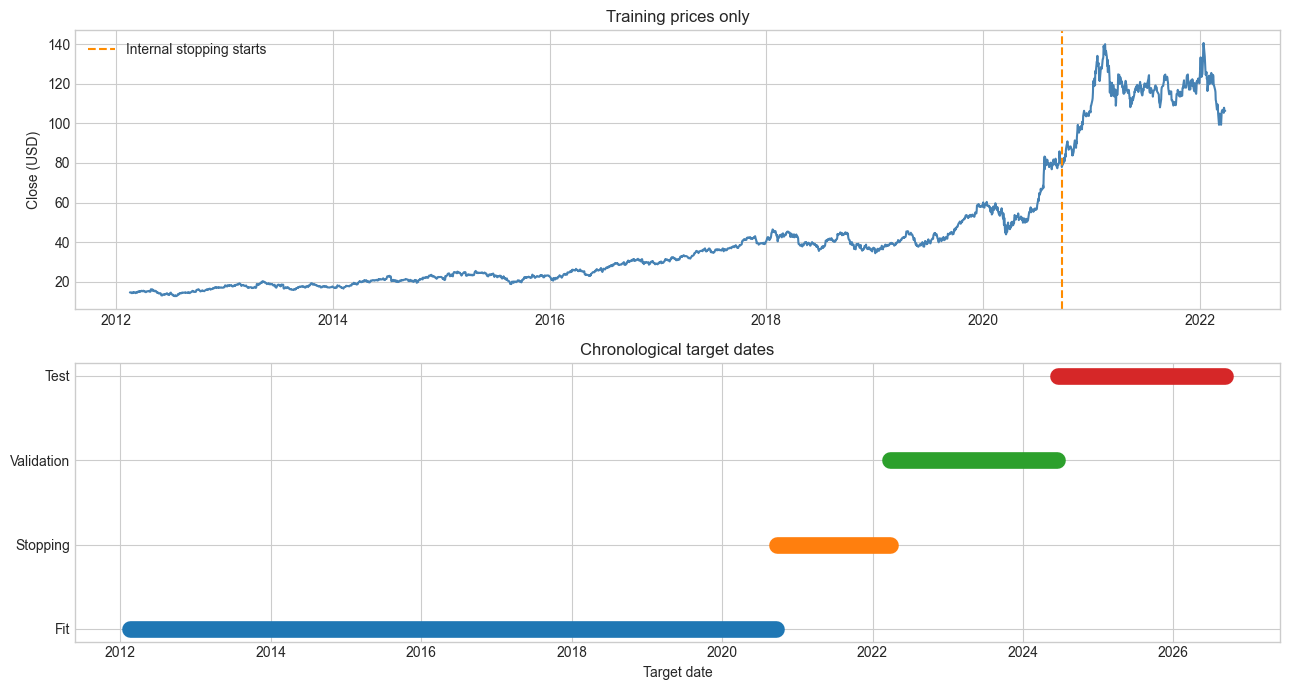

In [3]:
EXCLUDED = {'Date': 'Timestamp/index', 'Adj Close': 'No point-in-time adjustment provenance'}
ALL_FEATURES = [c for c in numeric_columns if c not in EXCLUDED]
FEATURE_SETS = {'close_only': ['Close'],
                'ohlcv': ['Open', 'High', 'Low', 'Close', 'Volume'],
                'all_features': ALL_FEATURES}
aligned = raw.rename(columns={'Date': 'Origin_Date'}).copy()
aligned['Origin_Row'] = np.arange(len(raw))
aligned['Target_Date'] = aligned['Origin_Date'].shift(-1)
aligned['Target_Close'] = aligned['Close'].shift(-1)
data = aligned.dropna(subset=ALL_FEATURES + ['Target_Date', 'Target_Close']).reset_index(drop=True)
assert len(data) > 500 and data['Target_Date'].is_unique
assert (data['Origin_Date'] < data['Target_Date']).all()
train_end = int(len(data) * TRAIN_FRACTION)
validation_end = int(len(data) * (TRAIN_FRACTION + VALIDATION_FRACTION))
train_base = data.iloc[:train_end].copy()
validation = data.iloc[train_end:validation_end].copy()
test = data.iloc[validation_end:].copy()
assert train_base['Target_Date'].max() < validation['Target_Date'].min()
assert validation['Target_Date'].max() < test['Target_Date'].min()

complete_inputs = raw[ALL_FEATURES].notna().all(axis=1)
FEATURE_START_ROW = int(np.flatnonzero(complete_inputs.to_numpy())[0])
assert complete_inputs.iloc[FEATURE_START_ROW:].all(), 'Unexpected interior missing features; inspect the source.'
FIRST_ORIGIN_ROW = FEATURE_START_ROW + max(LOOKBACKS) - 1
train = train_base.loc[train_base['Origin_Row'] >= FIRST_ORIGIN_ROW].copy()
assert len(train) > 500
assert validation['Origin_Row'].min() >= FIRST_ORIGIN_ROW
assert test['Origin_Row'].min() >= FIRST_ORIGIN_ROW
inner_end = int(len(train) * (1 - STOPPING_FRACTION))
fit_train = train.iloc[:inner_end].copy()
stopping = train.iloc[inner_end:].copy()
assert fit_train['Target_Date'].max() <= stopping['Origin_Date'].min()
assert stopping['Target_Date'].max() <= validation['Origin_Date'].min()
assert validation['Target_Date'].max() <= test['Origin_Date'].min()

split_summary = pd.DataFrame([
    {'split': label, 'rows': len(frame), 'first_origin': frame['Origin_Date'].min(),
     'last_origin': frame['Origin_Date'].max(), 'first_target': frame['Target_Date'].min(),
     'last_target': frame['Target_Date'].max()}
    for label, frame in [('train_original_boundary', train_base), ('train_window_eligible', train),
                         ('fit_train', fit_train), ('early_stopping', stopping),
                         ('validation', validation), ('test', test)]])
display(split_summary)
display(data[['Origin_Date', 'Close', 'Target_Date', 'Target_Close']].head())
split_summary.to_csv(RUN_DIR / 'splits.csv', index=False)
print('Additional training targets removed for common window warm-up:', len(train_base) - len(train))
print('Validation and test dates retain the existing notebook boundaries.')

CONFIGS = []
for feature_set, lookback, hidden_size, num_layers in product(FEATURE_SETS, LOOKBACKS, HIDDEN_SIZES, LAYER_COUNTS):
    CONFIGS.append({'id': f'{feature_set}_w{lookback}_h{hidden_size}_l{num_layers}',
                    'feature_set': feature_set, 'lookback': lookback, 'hidden_size': hidden_size,
                    'num_layers': num_layers, 'dropout': DROPOUT})
CONFIG_BY_ID = {c['id']: c for c in CONFIGS}
assert len(CONFIGS) == 24
display(pd.DataFrame(CONFIGS))
pd.DataFrame(CONFIGS).to_csv(RUN_DIR / 'search_grid.csv', index=False)

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].plot(train['Target_Date'], train['Target_Close'], color='steelblue')
axes[0].axvline(stopping['Target_Date'].min(), color='darkorange', linestyle='--', label='Internal stopping starts')
axes[0].set(title='Training prices only', ylabel='Close (USD)')
axes[0].legend()
for row, (label, frame) in enumerate([('Fit', fit_train), ('Stopping', stopping), ('Validation', validation), ('Test', test)]):
    axes[1].plot([frame['Target_Date'].min(), frame['Target_Date'].max()], [row, row], linewidth=12)
axes[1].set(yticks=range(4), yticklabels=['Fit', 'Stopping', 'Validation', 'Test'],
            title='Chronological target dates', xlabel='Target date')
finish_plot('01_data_and_splits')


## 4. Fold-specific scaling and memory-efficient windows

Volume uses `log1p`; every other input is standardized with a scaler fitted only to the historical input rows available to the weight-fitting period. Target scaling is fitted only on that period's next-day closing prices. Test values may fall outside the training range; no clipping or refitting on them is performed.

`WindowDataset` keeps a 2D feature matrix and returns slices of shape `(lookback, features)`. A batch has shape `(batch, lookback, features)`. The separate `anchor` is today's close transformed using the target scaler. The target is tomorrow's close transformed with the same scaler. All windows end at their origin; targets come from the next row.

Training batches are chronological (`shuffle=False`), and hidden state resets for each window. Evaluation can batch independent windows because each window contains only its own available history. This is rolling one-day forecasting with fixed weights, not a single forecast of the entire future path.


In [4]:
def feature_values(frame, columns):
    values = frame[columns].astype(float).copy()
    if 'Volume' in columns:
        values['Volume'] = np.log1p(values['Volume'])
    return values.to_numpy(dtype=np.float64)

def fit_preprocessing(fit_frame, columns):
    last_origin = int(fit_frame['Origin_Row'].max())
    x_scaler = StandardScaler().fit(feature_values(raw.iloc[FEATURE_START_ROW:last_origin + 1], columns))
    y_scaler = StandardScaler().fit(fit_frame[['Target_Close']].to_numpy(dtype=np.float64))
    return {'x_scaler': x_scaler, 'y_scaler': y_scaler, 'features': list(columns),
            'volume_transform': 'log1p' if 'Volume' in columns else None,
            'fit_last_origin': str(fit_frame['Origin_Date'].max().date()),
            'fit_last_target': str(fit_frame['Target_Date'].max().date())}

def scaled_arrays(preprocessing):
    # Earlier warm-up rows are never sampled; keep them NaN instead of backfilling.
    x = np.full((len(raw), len(preprocessing['features'])), np.nan, dtype=np.float32)
    x[FEATURE_START_ROW:] = preprocessing['x_scaler'].transform(
        feature_values(raw.iloc[FEATURE_START_ROW:], preprocessing['features'])).astype(np.float32)
    anchors = preprocessing['y_scaler'].transform(raw[['Close']].to_numpy()).reshape(-1).astype(np.float32)
    assert np.isfinite(x[FEATURE_START_ROW:]).all() and np.isfinite(anchors).all()
    return x, anchors

class WindowDataset(Dataset):
    def __init__(self, frame, x, anchors, lookback, preprocessing):
        self.origins = frame['Origin_Row'].to_numpy(dtype=np.int64)
        self.x = x
        self.anchors = anchors
        self.lookback = int(lookback)
        self.targets = preprocessing['y_scaler'].transform(
            frame[['Target_Close']].to_numpy()).reshape(-1).astype(np.float32)
        assert self.origins.min() - self.lookback + 1 >= FEATURE_START_ROW
        np.testing.assert_allclose(frame['Target_Close'].to_numpy(),
                                   raw['Close'].to_numpy()[self.origins + 1])
    def __len__(self):
        return len(self.origins)
    def __getitem__(self, index):
        origin = self.origins[index]
        window = self.x[origin - self.lookback + 1:origin + 1]
        return torch.from_numpy(window), torch.tensor(self.anchors[origin]), torch.tensor(self.targets[index])

def make_loader(frame, x, anchors, lookback, preprocessing):
    dataset = WindowDataset(frame, x, anchors, lookback, preprocessing)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                      pin_memory=False, drop_last=False)

def scores(frame, predictions, scale_frame):
    actual = frame['Target_Close'].to_numpy(dtype=np.float64)
    predictions = np.asarray(predictions, dtype=np.float64)
    current = frame['Close'].to_numpy(dtype=np.float64)
    assert predictions.shape == actual.shape and np.isfinite(predictions).all()
    mae = mean_absolute_error(actual, predictions)
    mse = mean_squared_error(actual, predictions)
    rmse = float(np.sqrt(mse))
    persistence_rmse = float(np.sqrt(mean_squared_error(actual, current)))
    scale = float(np.mean(np.abs(scale_frame['Target_Close'] - scale_frame['Close'])))
    if scale <= 0 or persistence_rmse <= 0:
        raise ValueError('Degenerate baseline scale; investigate the data.')
    return {'MAE': float(mae), 'MSE': float(mse), 'RMSE': rmse,
            'MAPE_pct': float(np.mean(np.abs((actual - predictions) / actual)) * 100),
            'R2': float(r2_score(actual, predictions)), 'MASE': float(mae / scale),
            'Direction_accuracy_pct': float(np.mean(np.sign(predictions - current) == np.sign(actual - current)) * 100),
            'RMSE_skill_pct': float((1 - rmse / persistence_rmse) * 100)}


## 5. LSTM units, stacked hidden layers, and the price connection

`nn.LSTM` reads the window in forward time. We use the last layer's final hidden state, apply dropout, and map it to a scalar correction. `num_layers=2` stacks two recurrent layers; it does not mean two arbitrary dense layers. Internal LSTM dropout applies only between stacked layers, so it is zero for a one-layer LSTM; the explicit output dropout is used for both depths.

The model output is `scaled_today_close + correction`. The correction head starts at zero, so the initial forecast is persistence. Training minimizes MSE against the scaled **next-day price**. Since scaling is an affine transform fixed within each fit, this loss is proportional to dollar-price MSE. The model is free to learn positive or negative corrections. AdamW, mild weight decay, and gradient clipping are fixed across candidates.

The sanity check below, when executed, checks shape, time alignment, and the initial persistence prediction. It does not train a model.


In [5]:
class PriceCorrectionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0,
                            bidirectional=False)
        self.output_dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, 1)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)
    def forward(self, windows, anchors):
        _, (hidden, _) = self.lstm(windows)
        correction = self.head(self.output_dropout(hidden[-1])).squeeze(-1)
        return anchors + correction

def new_model(config, input_size):
    return PriceCorrectionLSTM(input_size, config['hidden_size'], config['num_layers'], config['dropout'])

def cpu_state(model):
    return {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}

@torch.no_grad()
def predict_prices(model, loader, preprocessing, device=DEVICE):
    model.eval()
    batches = []
    for windows, anchors, _ in loader:
        output = model(windows.to(device), anchors.to(device))
        batches.append(output.cpu().numpy())
    scaled = np.concatenate(batches).reshape(-1, 1)
    values = preprocessing['y_scaler'].inverse_transform(scaled.astype(np.float64)).reshape(-1)
    if not np.isfinite(values).all():
        raise FloatingPointError('Non-finite price predictions.')
    return values

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_squared_error, count = 0.0, 0
    with torch.set_grad_enabled(training):
        for windows, anchors, targets in loader:
            windows, anchors, targets = windows.to(DEVICE), anchors.to(DEVICE), targets.to(DEVICE)
            if training:
                optimizer.zero_grad(set_to_none=True)
            predictions = model(windows, anchors)
            loss = nn.functional.mse_loss(predictions, targets)
            if not torch.isfinite(loss):
                raise FloatingPointError('Non-finite training/evaluation loss.')
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP, error_if_nonfinite=True)
                optimizer.step()
            total_squared_error += float(loss.detach().cpu()) * len(targets)
            count += len(targets)
    return total_squared_error / count

sanity_preprocessing = fit_preprocessing(fit_train, FEATURE_SETS['ohlcv'])
sanity_x, sanity_anchors = scaled_arrays(sanity_preprocessing)
sanity_loader = make_loader(fit_train.iloc[:3], sanity_x, sanity_anchors, max(LOOKBACKS), sanity_preprocessing)
sanity_model = PriceCorrectionLSTM(5, 32, 2, DROPOUT).to(DEVICE)
sanity_prediction = predict_prices(sanity_model, sanity_loader, sanity_preprocessing)
np.testing.assert_allclose(sanity_prediction, fit_train['Close'].iloc[:3], atol=1e-4, rtol=1e-6)
print('Window/target alignment and initial persistence check passed.')
del sanity_model, sanity_loader, sanity_x, sanity_anchors, sanity_preprocessing
release_memory()


Window/target alignment and initial persistence check passed.


## 6. A bounded single-trial trainer

For each fit, scalers learn only from `fit_train`. Each epoch trains on that period and measures loss on the chronological internal-stopping period. The best internal-stopping weights are copied to CPU and restored before external validation. `MIN_DELTA` controls patience, while the absolute best finite stopping loss determines the saved checkpoint.

The same time/epoch budgets apply to every candidate. A time-limited fit is labeled `time_budget`, and its result is a comparison under that computational budget, not a fully optimized architecture. We record actual epochs, best epoch, parameters, stopping reason, training time, and validation scores. We do not silently change batch size or device for one candidate. Failed fits are recorded. KeyboardInterrupt is allowed to stop the run.

Each completed trial stores its learning curve, best CPU checkpoint, preprocessing, and validation predictions. Rerunning the search cell reuses already completed trial results in memory; a new kernel starts a new experiment. Partial files are evidence/checkpoints, not an automatic cross-session resume mechanism.


In [6]:
def fit_trial(config, seed):
    seed_everything(seed)
    trial_id = f"{config['id']}_seed{seed}"
    path = TRIAL_DIR / trial_id
    path.mkdir(exist_ok=True)
    model = optimizer = None
    started = time.perf_counter()
    try:
        preprocessing = fit_preprocessing(fit_train, FEATURE_SETS[config['feature_set']])
        x, anchors = scaled_arrays(preprocessing)
        fit_loader = make_loader(fit_train, x, anchors, config['lookback'], preprocessing)
        stop_loader = make_loader(stopping, x, anchors, config['lookback'], preprocessing)
        model = new_model(config, len(preprocessing['features'])).to(DEVICE)
        parameter_count = sum(p.numel() for p in model.parameters())
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        best_loss, patience_reference, best_epoch = float('inf'), float('inf'), 0
        best_state, stale_epochs, curve = None, 0, []
        stop_reason = 'max_epochs'
        for epoch in range(1, MAX_EPOCHS + 1):
            train_loss = run_epoch(model, fit_loader, optimizer)
            stop_loss = run_epoch(model, stop_loader)
            elapsed = time.perf_counter() - started
            curve.append({'epoch': epoch, 'train_scaled_MSE': train_loss,
                          'stopping_scaled_MSE': stop_loss, 'elapsed_seconds': elapsed})
            if stop_loss < best_loss:
                best_loss, best_epoch, best_state = stop_loss, epoch, cpu_state(model)
            if stop_loss < patience_reference - MIN_DELTA:
                patience_reference, stale_epochs = stop_loss, 0
            else:
                stale_epochs += 1
            if epoch == 1 or epoch % 10 == 0:
                print(f'  epoch {epoch:02d}: train={train_loss:.6g}, stopping={stop_loss:.6g}', flush=True)
            if stale_epochs >= PATIENCE:
                stop_reason = 'early_stopping'
                break
            if elapsed >= MAX_TRIAL_SECONDS:
                stop_reason = 'time_budget'
                break
        if best_state is None:
            raise RuntimeError('No finite internal-stopping checkpoint.')
        model.load_state_dict(best_state)
        validation_loader = make_loader(validation, x, anchors, config['lookback'], preprocessing)
        predictions = predict_prices(model, validation_loader, preprocessing)
        metrics = scores(validation, predictions, fit_train)
        record = {'trial_id': trial_id, 'config_id': config['id'], **config, 'seed': seed,
                  'status': 'ok', 'error': '', 'n_features': len(preprocessing['features']),
                  'parameters': parameter_count, 'epochs_run': len(curve), 'best_epoch': best_epoch,
                  'stopping_loss': float(best_loss), 'stop_reason': stop_reason,
                  'elapsed_seconds': time.perf_counter() - started, **metrics}
        pd.DataFrame(curve).to_csv(path / 'learning_curve.csv', index=False)
        torch.save({'state_dict': best_state, 'config': config, 'input_size': len(preprocessing['features']),
                    'seed': seed, 'best_epoch': best_epoch}, path / 'best_weights.pt')
        joblib.dump(preprocessing, path / 'preprocessing.joblib')
        forecast = validation[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
        forecast['Prediction'] = predictions
        forecast.to_csv(path / 'validation_predictions.csv', index=False)
        (path / 'result.json').write_text(json.dumps(record, indent=2, allow_nan=False), encoding='utf-8')
        print(f"  validation RMSE=${metrics['RMSE']:.4f}; best epoch={best_epoch}; {stop_reason}", flush=True)
        return record
    finally:
        del model, optimizer
        release_memory()

trial_records = {}
def obtain_trial(config, seed):
    key = (config['id'], seed)
    if key in trial_records:
        print('Reusing completed trial:', key)
        return trial_records[key]
    print(f"Training {config['id']} | seed={seed}", flush=True)
    try:
        record = fit_trial(config, seed)
    except Exception as exc:
        record = {'config_id': config['id'], **config, 'seed': seed, 'status': 'failed',
                  'error': f'{type(exc).__name__}: {exc}', 'RMSE': np.nan}
        print('FAILED:', record['error'], flush=True)
    trial_records[key] = record
    pd.DataFrame(trial_records.values()).to_csv(RUN_DIR / 'all_trial_results.csv', index=False)
    return record


## 7. Screen all 24 configurations on the same validation dates

Train one model at a time. Compare with the persistence forecast `tomorrow = today`. The screening stage ranks by validation RMSE, then MAE, parameter count, and ID for deterministic tie-breaking. Failed fits remain in the table. A high R² alone cannot justify selecting an LSTM.

The heatmaps compare units and layer depth at each lookback and feature set; missing cells indicate failed trials. The bar plot summarizes the strongest screening result per feature set, not a significance test.


Persistence validation RMSE: 2.2316583838383823
Training close_only_w20_h32_l1 | seed=42
  epoch 01: train=0.00250508, stopping=0.0328871
  validation RMSE=$2.2333; best epoch=1; early_stopping
Training close_only_w20_h32_l2 | seed=42
  epoch 01: train=0.00250045, stopping=0.032869
  validation RMSE=$2.2309; best epoch=1; early_stopping
Training close_only_w20_h64_l1 | seed=42
  epoch 01: train=0.00251071, stopping=0.032912
  validation RMSE=$2.2277; best epoch=3; early_stopping
Training close_only_w20_h64_l2 | seed=42
  epoch 01: train=0.00250237, stopping=0.0328526
  validation RMSE=$2.2312; best epoch=1; early_stopping
Training close_only_w60_h32_l1 | seed=42
  epoch 01: train=0.00250508, stopping=0.0328872
  validation RMSE=$2.2333; best epoch=1; early_stopping
Training close_only_w60_h32_l2 | seed=42
  epoch 01: train=0.00250062, stopping=0.0328688
  validation RMSE=$2.2281; best epoch=2; early_stopping
Training close_only_w60_h64_l1 | seed=42
  epoch 01: train=0.00251071, stoppin

,feature_set,lookback,hidden_size,num_layers,RMSE,MAE,R2,best_epoch,stop_reason,elapsed_seconds
2,close_only,20,64,1,2.227679,1.610963,0.990274,3,early_stopping,3.218770
6,close_only,60,64,1,2.227680,1.610963,0.990274,3,early_stopping,3.012824
19,all_features,20,64,2,2.227960,1.611237,0.990272,1,early_stopping,2.797569
5,close_only,60,32,2,2.228142,1.612573,0.990270,2,early_stopping,2.999780
21,all_features,60,32,2,2.228720,1.610246,0.990265,1,early_stopping,2.810602
17,all_features,20,32,2,2.229113,1.609713,0.990262,1,early_stopping,2.758542
12,ohlcv,60,32,1,2.229562,1.608713,0.990258,1,early_stopping,2.386961
8,ohlcv,20,32,1,2.229599,1.608712,0.990257,1,early_stopping,2.030959
9,ohlcv,20,32,2,2.230392,1.608369,0.990250,1,early_stopping,2.376484
13,ohlcv,60,32,2,2.230688,1.607596,0.990248,1,early_stopping,2.645437


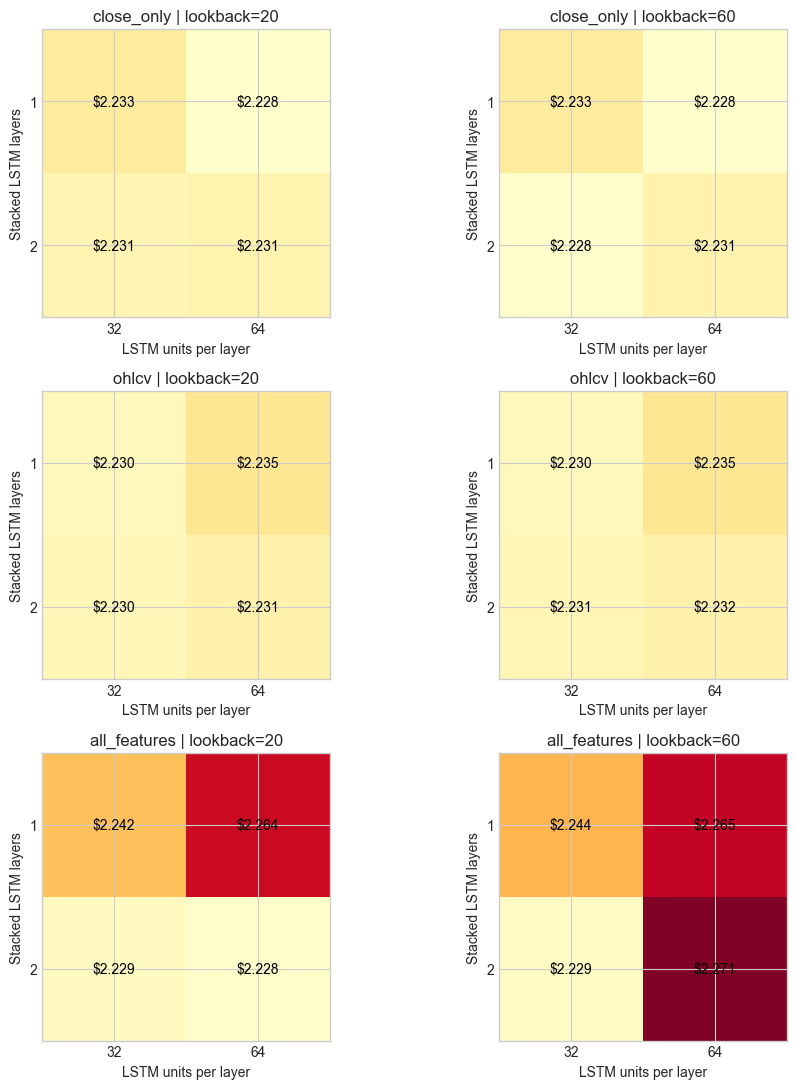

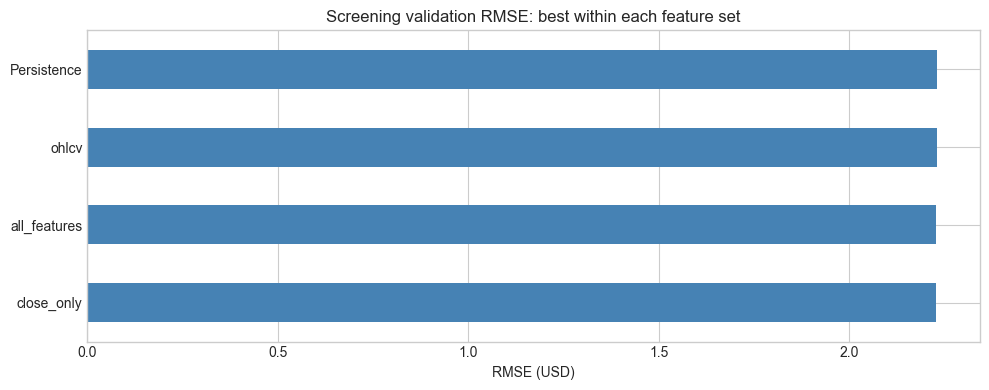

In [7]:
baseline_validation = scores(validation, validation['Close'].to_numpy(), fit_train)
print('Persistence validation RMSE:', baseline_validation['RMSE'])
screening_records = [obtain_trial(config, SEEDS[0]) for config in CONFIGS]
screening = pd.DataFrame(screening_records)
screening.to_csv(RUN_DIR / 'screening_results.csv', index=False)
screening_ok = screening.loc[screening['status'].eq('ok') & np.isfinite(screening['RMSE'])].copy()
if screening_ok.empty:
    raise RuntimeError('All LSTM fits failed. Inspect all_trial_results.csv; test evaluation has not started.')
screening_ranked = screening_ok.sort_values(['RMSE', 'MAE', 'parameters', 'config_id'])
display(screening_ranked[['feature_set', 'lookback', 'hidden_size', 'num_layers',
                           'RMSE', 'MAE', 'R2', 'best_epoch', 'stop_reason', 'elapsed_seconds']])
if (screening['status'] != 'ok').any():
    display(screening.loc[screening['status'] != 'ok', ['config_id', 'error']])

fig, axes = plt.subplots(len(FEATURE_SETS), len(LOOKBACKS), figsize=(10, 11), squeeze=False)
vmin, vmax = screening_ok['RMSE'].min(), screening_ok['RMSE'].max()
for row, name in enumerate(FEATURE_SETS):
    for col, lookback in enumerate(LOOKBACKS):
        table = screening_ok.loc[(screening_ok['feature_set'] == name) & (screening_ok['lookback'] == lookback)]
        matrix = table.pivot(index='num_layers', columns='hidden_size', values='RMSE').reindex(index=LAYER_COUNTS, columns=HIDDEN_SIZES)
        ax = axes[row, col]
        ax.imshow(matrix.to_numpy(), cmap='YlOrRd', vmin=vmin, vmax=vmax)
        for i in range(len(LAYER_COUNTS)):
            for j in range(len(HIDDEN_SIZES)):
                value = matrix.iloc[i, j]
                ax.text(j, i, 'failed' if pd.isna(value) else f'${value:.3f}', ha='center', va='center', color='black')
        ax.set(title=f'{name} | lookback={lookback}', xticks=range(len(HIDDEN_SIZES)), xticklabels=HIDDEN_SIZES,
               yticks=range(len(LAYER_COUNTS)), yticklabels=LAYER_COUNTS, xlabel='LSTM units per layer', ylabel='Stacked LSTM layers')
finish_plot('02_search_heatmaps')

family_best = screening_ranked.groupby('feature_set', sort=False).head(1)
comparison = family_best.set_index('feature_set')['RMSE'].copy()
comparison.loc['Persistence'] = baseline_validation['RMSE']
fig, ax = plt.subplots(figsize=(10, 4))
comparison.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set(title='Screening validation RMSE: best within each feature set', xlabel='RMSE (USD)', ylabel='')
finish_plot('03_feature_set_comparison')


## 8. Repeat the top two configurations across three seeds

Reuse seed 42 from screening and train seeds 123 and 2026. A finalist is eligible only if all three seed fits succeeded. Rank by mean validation RMSE, then its standard deviation, then mean MAE and parameter count. This reduces selection based on a lucky initialization but does not prove statistical significance. The reported standard deviation measures seed variability on one validation period, not a confidence interval for future performance.

If fewer than two configurations survived screening, repeat the available one and report that limitation. If no finalist completes all seeds, stop; do not use the test set to resolve failures. Freeze architecture, input features, lookback, seed policy, and final epoch count here. The final refit uses fixed seed 42 and the median best epoch of the winning configuration's three internal-stopping histories.


Reusing completed trial: ('close_only_w20_h64_l1', 42)
Training close_only_w20_h64_l1 | seed=123
  epoch 01: train=0.00251417, stopping=0.0329689
  validation RMSE=$2.2281; best epoch=3; early_stopping
Training close_only_w20_h64_l1 | seed=2026
  epoch 01: train=0.00251277, stopping=0.032909
  validation RMSE=$2.2374; best epoch=1; early_stopping
Reusing completed trial: ('close_only_w60_h64_l1', 42)
Training close_only_w60_h64_l1 | seed=123
  epoch 01: train=0.00251417, stopping=0.0329689
  validation RMSE=$2.2281; best epoch=3; early_stopping
Training close_only_w60_h64_l1 | seed=2026
  epoch 01: train=0.00251277, stopping=0.032909
  validation RMSE=$2.2374; best epoch=1; early_stopping


,config_id,mean_RMSE,std_RMSE,mean_MAE,parameters,median_best_epoch,time_limited_runs
0,close_only_w20_h64_l1,2.231068,0.005493,1.608832,17217,3,0
1,close_only_w60_h64_l1,2.231071,0.005490,1.608833,17217,3,0


Locked configuration: {'id': 'close_only_w20_h64_l1', 'feature_set': 'close_only', 'lookback': 20, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1}
Final seed: 42 | Final epochs: 3


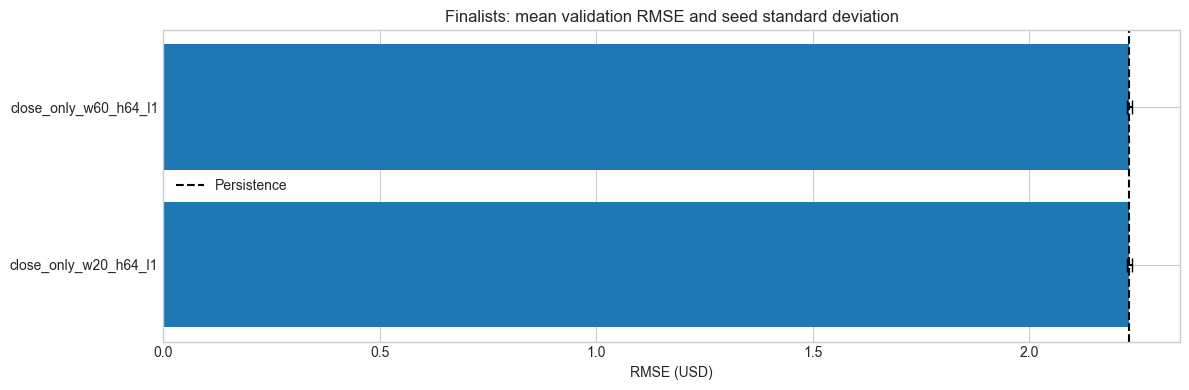

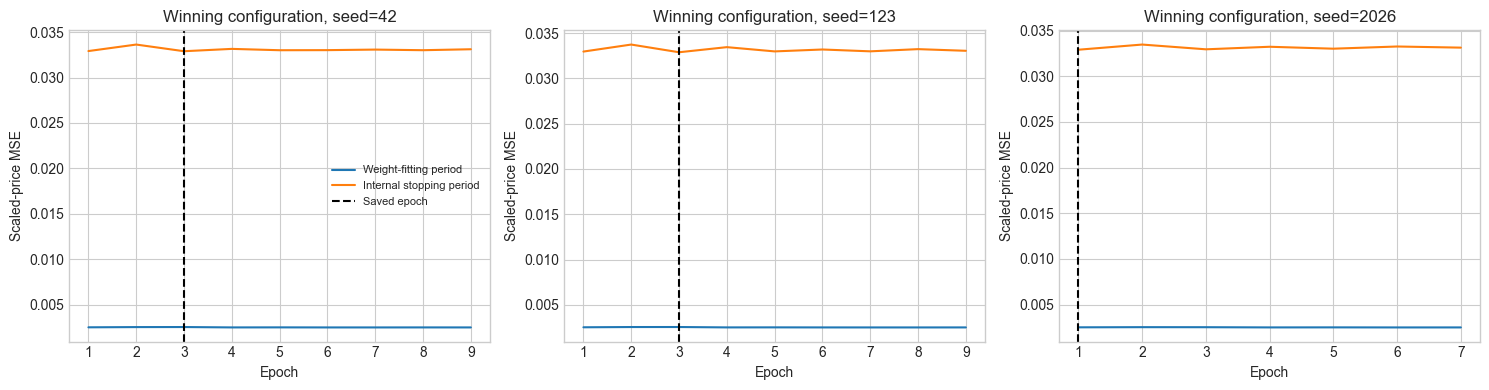

In [8]:
finalist_ids = screening_ranked.head(TOP_K)['config_id'].tolist()
if len(finalist_ids) < TOP_K:
    print('LIMITATION: fewer than two eligible screening configurations.')
repeat_records = [obtain_trial(CONFIG_BY_ID[config_id], seed) for config_id in finalist_ids for seed in SEEDS]
repeat_results = pd.DataFrame(repeat_records)
repeat_results.to_csv(RUN_DIR / 'seed_repeat_results.csv', index=False)
stability_rows = []
for config_id in finalist_ids:
    group = repeat_results.loc[repeat_results['config_id'] == config_id]
    good = group.loc[group['status'].eq('ok') & np.isfinite(group['RMSE'])]
    if len(good) != len(SEEDS):
        print('Ineligible finalist: incomplete successful seed repeats:', config_id)
        continue
    stability_rows.append({'config_id': config_id, 'mean_RMSE': float(good['RMSE'].mean()),
                           'std_RMSE': float(good['RMSE'].std(ddof=1)),
                           'mean_MAE': float(good['MAE'].mean()), 'parameters': int(good['parameters'].iloc[0]),
                           'median_best_epoch': int(np.median(good['best_epoch'])),
                           'time_limited_runs': int(good['stop_reason'].eq('time_budget').sum())})
if not stability_rows:
    raise RuntimeError('No finalist completed all seed repetitions. Inspect seed_repeat_results.csv.')
stability = pd.DataFrame(stability_rows).sort_values(['mean_RMSE', 'std_RMSE', 'mean_MAE', 'parameters', 'config_id'])
display(stability)
stability.to_csv(RUN_DIR / 'seed_stability.csv', index=False)
BEST_ID = str(stability.iloc[0]['config_id'])
BEST_CONFIG = CONFIG_BY_ID[BEST_ID].copy()
BEST_FEATURES = FEATURE_SETS[BEST_CONFIG['feature_set']]
FINAL_EPOCHS = max(1, int(stability.iloc[0]['median_best_epoch']))
print('Locked configuration:', BEST_CONFIG)
print('Final seed:', FINAL_SEED, '| Final epochs:', FINAL_EPOCHS)
if stability.iloc[0]['mean_RMSE'] >= baseline_validation['RMSE']:
    print('The winning LSTM did not beat persistence on mean validation RMSE. Report this outcome.')
if (stability['time_limited_runs'] > 0).any():
    print('Some finalist runs hit the time budget; conclusions are conditional on this compute budget.')

fig, ax = plt.subplots(figsize=(12, 4))
ax.barh(stability['config_id'], stability['mean_RMSE'], xerr=stability['std_RMSE'], capsize=5)
ax.axvline(baseline_validation['RMSE'], color='black', linestyle='--', label='Persistence')
ax.set(title='Finalists: mean validation RMSE and seed standard deviation', xlabel='RMSE (USD)')
ax.legend()
finish_plot('04_seed_stability')

fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 4), squeeze=False)
for ax, seed in zip(axes[0], SEEDS):
    curve = pd.read_csv(TRIAL_DIR / f'{BEST_ID}_seed{seed}' / 'learning_curve.csv')
    ax.plot(curve['epoch'], curve['train_scaled_MSE'], label='Weight-fitting period')
    ax.plot(curve['epoch'], curve['stopping_scaled_MSE'], label='Internal stopping period')
    chosen_epoch = int(repeat_results.loc[(repeat_results['config_id'] == BEST_ID) & (repeat_results['seed'] == seed), 'best_epoch'].iloc[0])
    ax.axvline(chosen_epoch, color='black', linestyle='--', label='Saved epoch')
    ax.set(title=f'Winning configuration, seed={seed}', xlabel='Epoch', ylabel='Scaled-price MSE')
axes[0, 0].legend(fontsize=8)
finish_plot('05_learning_curves')


## 9. Refit the locked model and save it before test evaluation

Combine eligible training targets (including the earlier stopping subset) with validation. Fit new scalers on this combined historical period and train a new model with the fixed seed and median epoch count. No early stopping or architecture changes use test data. The final fit is capped by `MAX_EPOCHS` through its selected epoch count; it does not use the tuning time cutoff because the training duration is already locked. It trains on more samples, so it can take longer than a tuning fit.

Save CPU `state_dict` tensors, architecture settings, feature order, and scalers. The class definition is included in a generated `model_definition.py`, allowing reuse without rerunning the notebook search. A model file alone is insufficient: preprocessing and the lookback convention must accompany it.


In [9]:
history = pd.concat([train, validation], ignore_index=True)
assert history['Target_Date'].max() < test['Target_Date'].min()
assert history['Target_Date'].max() <= test['Origin_Date'].min()
seed_everything(FINAL_SEED)
final_preprocessing = fit_preprocessing(history, BEST_FEATURES)
final_x, final_anchors = scaled_arrays(final_preprocessing)
final_loader = make_loader(history, final_x, final_anchors, BEST_CONFIG['lookback'], final_preprocessing)
final_model = new_model(BEST_CONFIG, len(BEST_FEATURES)).to(DEVICE)
final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
final_curve = []
final_started = time.perf_counter()
for epoch in range(1, FINAL_EPOCHS + 1):
    loss = run_epoch(final_model, final_loader, final_optimizer)
    final_curve.append({'epoch': epoch, 'train_scaled_MSE': loss})
    if epoch == 1 or epoch % 5 == 0 or epoch == FINAL_EPOCHS:
        print(f'Final refit epoch {epoch}/{FINAL_EPOCHS}: MSE={loss:.6g}', flush=True)
final_fit_seconds = time.perf_counter() - final_started
del final_optimizer
final_model.eval()
pd.DataFrame(final_curve).to_csv(RUN_DIR / 'final_training_curve.csv', index=False)
checkpoint = {'state_dict': cpu_state(final_model), 'architecture': BEST_CONFIG,
              'input_size': len(BEST_FEATURES), 'features': BEST_FEATURES,
              'target': 'next trading day unadjusted Close', 'seed': FINAL_SEED,
              'epochs': FINAL_EPOCHS, 'persistence_connection': True}
MODEL_FILE = RUN_DIR / 'selected_model.pt'
PREPROCESSING_FILE = RUN_DIR / 'preprocessing.joblib'
torch.save(checkpoint, MODEL_FILE)
joblib.dump(final_preprocessing, PREPROCESSING_FILE)
model_definition = '''from torch import nn

class PriceCorrectionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0,
                            bidirectional=False)
        self.output_dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, 1)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)
    def forward(self, windows, anchors):
        _, (hidden, _) = self.lstm(windows)
        return anchors + self.head(self.output_dropout(hidden[-1])).squeeze(-1)
'''
(RUN_DIR / 'model_definition.py').write_text(model_definition, encoding='utf-8')
print('Saved locked model and preprocessing:', RUN_DIR)


Final refit epoch 1/3: MSE=0.00146236
Final refit epoch 3/3: MSE=0.00144122
Saved locked model and preprocessing: f:\SEM-7\Time Series Analysis\Project\models\lstm\20260923T041634383000Z


## 10. Test once, compare with persistence, and verify saved-model reload

Make rolling next-day predictions using the locked model in `eval()` mode without gradients. Later test windows may use earlier realized test observations because they would be known at those later forecast origins. No weights/scalers update during testing. These are not all predictions issued on the first test date.

Report MAE, MSE, RMSE, MAPE, R², MASE, directional accuracy, and improvement over persistence. MASE uses the train + validation persistence error as its final scale. No trades or profit claims are made. This deterministic LSTM supplies point forecasts; no unsupported confidence band is plotted.

Reload the saved checkpoint with `weights_only=True` and compare predictions for the first batch. Cross-device float32 rounding permits a small tolerance. Load joblib artifacts only from trusted sources.


In [10]:
test_loader = make_loader(test, final_x, final_anchors, BEST_CONFIG['lookback'], final_preprocessing)
test_predictions = predict_prices(final_model, test_loader, final_preprocessing)
test_metrics = pd.DataFrame({
    'LSTM_selected': scores(test, test_predictions, history),
    'Persistence': scores(test, test['Close'].to_numpy(), history),
}).T
test_metrics.index.name = 'model'
display(test_metrics)
test_metrics.to_csv(RUN_DIR / 'test_metrics.csv')
test_export = test[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
test_export['Prediction'] = test_predictions
test_export['Persistence'] = test['Close'].to_numpy()
test_export['Error_actual_minus_predicted'] = test_export['Target_Close'] - test_predictions
test_export['Predicted_return'] = test_predictions / test_export['Close'] - 1
test_export['Actual_return'] = test_export['Target_Close'] / test_export['Close'] - 1
test_export.to_csv(RUN_DIR / 'test_predictions.csv', index=False)

loaded = torch.load(MODEL_FILE, map_location='cpu', weights_only=True)
loaded_preprocessing = joblib.load(PREPROCESSING_FILE)
reload_x, reload_anchors = scaled_arrays(loaded_preprocessing)
reload_model = new_model(loaded['architecture'], loaded['input_size'])
reload_model.load_state_dict(loaded['state_dict'])
reload_loader = make_loader(test.iloc[:BATCH_SIZE], reload_x, reload_anchors,
                            loaded['architecture']['lookback'], loaded_preprocessing)
reload_predictions = predict_prices(reload_model, reload_loader, loaded_preprocessing, device=torch.device('cpu'))
np.testing.assert_allclose(reload_predictions, test_predictions[:len(reload_predictions)], atol=2e-3, rtol=1e-5)
print('Reloaded CPU model reproduces the original forecasts within float32 tolerance.')
del reload_model, reload_loader, reload_x, reload_anchors
release_memory()


,MAE,MSE,RMSE,MAPE_pct,R2,MASE,Direction_accuracy_pct,RMSE_skill_pct
model,,,,,,,,
LSTM_selected,5.219411,54.634569,7.39152,1.964408,0.993510,6.499443,53.130590,0.13174
Persistence,5.232576,54.778805,7.40127,1.967970,0.993493,6.515837,0.178891,0.00000


Reloaded CPU model reproduces the original forecasts within float32 tolerance.


## 11. Forecast and error plots

Show the full test period plus a close-up, errors through time, actual versus predicted values, and 20-observation rolling MAE. Daily predicted versus actual returns help reveal whether an apparently accurate price forecast is mostly copying today's close. A wide range of rising prices can make R² look impressive even when the model adds no value over persistence.


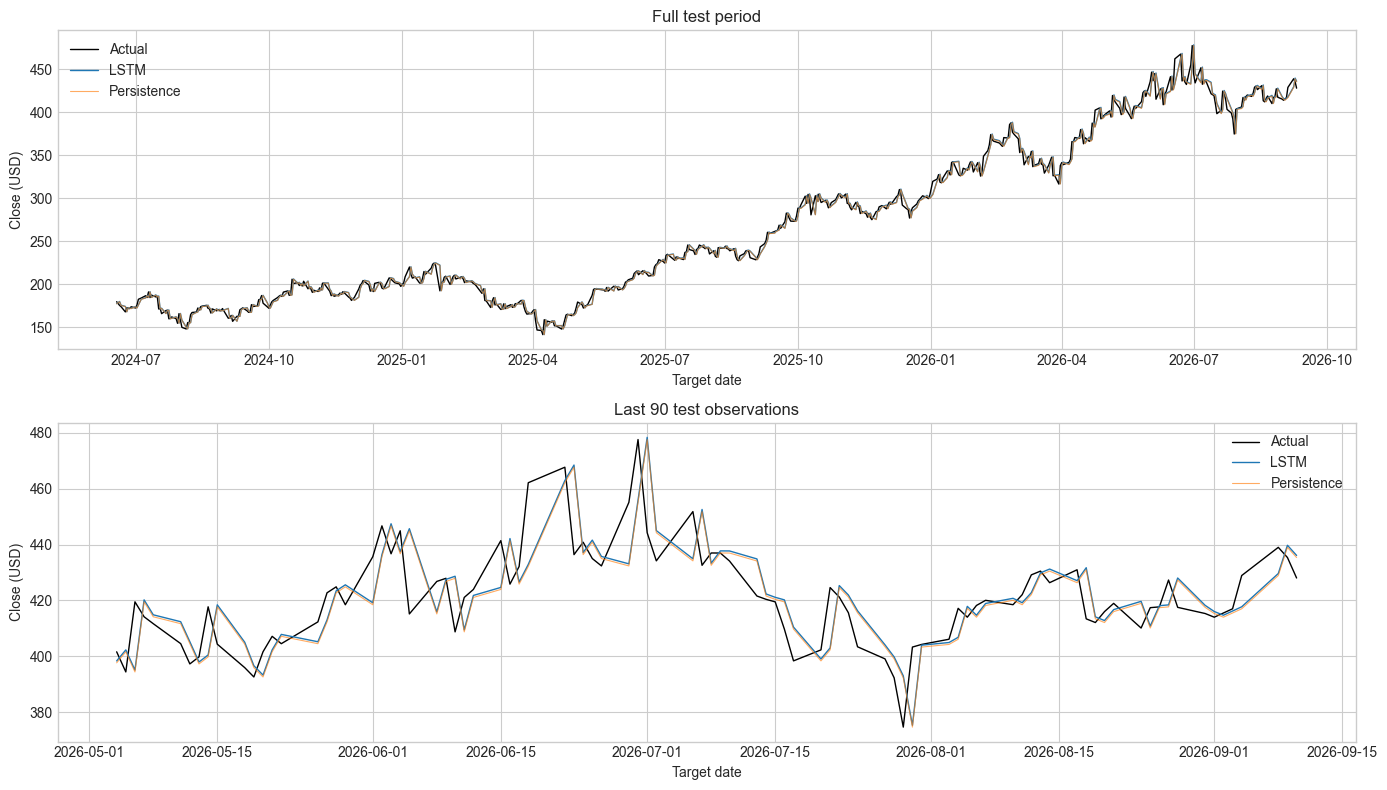

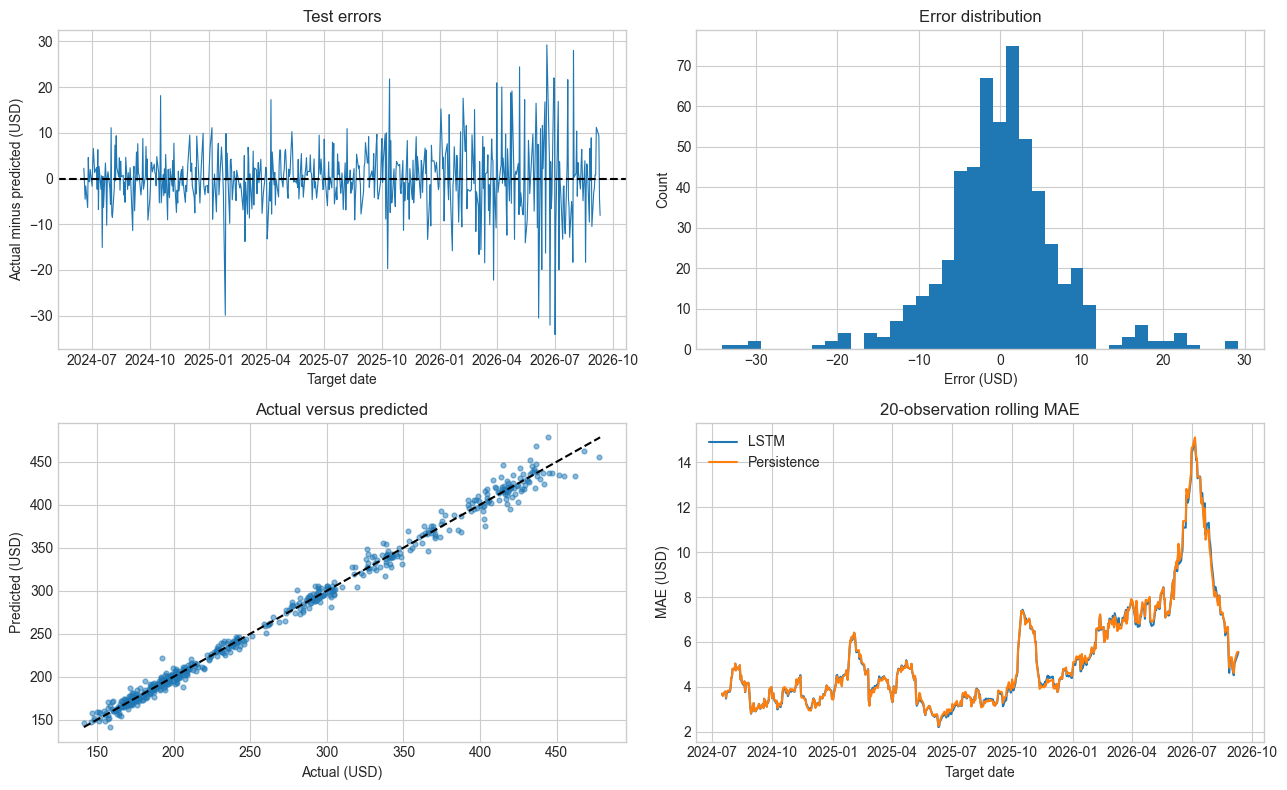

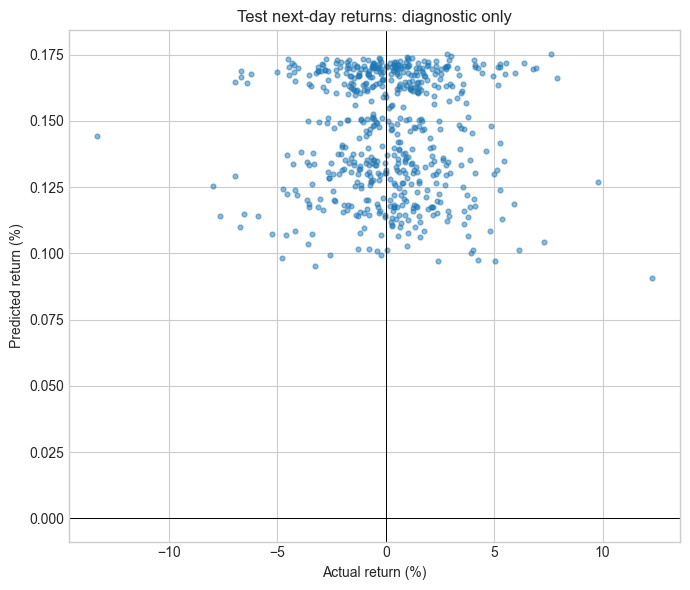

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax, frame, title in [(axes[0], test_export, 'Full test period'),
                         (axes[1], test_export.tail(90), 'Last 90 test observations')]:
    ax.plot(frame['Target_Date'], frame['Target_Close'], color='black', linewidth=1, label='Actual')
    ax.plot(frame['Target_Date'], frame['Prediction'], linewidth=1, label='LSTM')
    ax.plot(frame['Target_Date'], frame['Persistence'], linewidth=0.8, alpha=0.65, label='Persistence')
    ax.set(title=title, xlabel='Target date', ylabel='Close (USD)')
    ax.legend()
finish_plot('06_test_forecasts')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(test_export['Target_Date'], test_export['Error_actual_minus_predicted'], linewidth=0.8)
axes[0, 0].axhline(0, color='black', linestyle='--')
axes[0, 0].set(title='Test errors', xlabel='Target date', ylabel='Actual minus predicted (USD)')
axes[0, 1].hist(test_export['Error_actual_minus_predicted'], bins=40)
axes[0, 1].set(title='Error distribution', xlabel='Error (USD)', ylabel='Count')
axes[1, 0].scatter(test_export['Target_Close'], test_export['Prediction'], s=12, alpha=0.5)
limits = [min(test_export['Target_Close'].min(), test_export['Prediction'].min()),
          max(test_export['Target_Close'].max(), test_export['Prediction'].max())]
axes[1, 0].plot(limits, limits, '--', color='black')
axes[1, 0].set(title='Actual versus predicted', xlabel='Actual (USD)', ylabel='Predicted (USD)')
for column, label in [('Prediction', 'LSTM'), ('Persistence', 'Persistence')]:
    rolling = (test_export['Target_Close'] - test_export[column]).abs().rolling(20).mean()
    axes[1, 1].plot(test_export['Target_Date'], rolling, label=label)
axes[1, 1].set(title='20-observation rolling MAE', xlabel='Target date', ylabel='MAE (USD)')
axes[1, 1].legend()
finish_plot('07_test_errors')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(test_export['Actual_return'] * 100, test_export['Predicted_return'] * 100, s=12, alpha=0.5)
ax.axhline(0, color='black', linewidth=0.7)
ax.axvline(0, color='black', linewidth=0.7)
ax.set(title='Test next-day returns: diagnostic only', xlabel='Actual return (%)', ylabel='Predicted return (%)')
finish_plot('08_return_diagnostic')


## 12. Reproducibility manifest and report-ready conclusion

The run folder contains the selected model, scalers, importable architecture, all trial settings/results, learning curves, plots, and dated predictions. The manifest records the data hash, versions, timing limits, target convention, frozen architecture, and actual test results. `latest_run.json` is written only on successful completion of this final cell.

Describe the winner as **best among the tested configurations under this compute budget**, selected using mean validation RMSE across three seeds. Report failures, time-limited runs, and whether persistence wins. Choosing among ARIMA, SARIMA, and LSTM using their test scores would reuse the test period for selection; use validation evidence for a cross-family choice instead. Scalers and network architecture differ between families, but target dates and reported dollar metrics remain comparable.


In [12]:
winner = stability.iloc[0]
selected_test = test_metrics.loc['LSTM_selected']
baseline_test = test_metrics.loc['Persistence']
manifest = {
    'run_id': RUN_ID, 'data_file': str(DATA_FILE.relative_to(ROOT)),
    'data_sha256': hashlib.sha256(DATA_FILE.read_bytes()).hexdigest(),
    'source': 'Master from local Yahoo Finance data; Google comparison in project.',
    'raw_rows': len(raw), 'canonical_rows': len(data), 'eligible_training_windows': len(train),
    'splits': json.loads(split_summary.to_json(orient='records', date_format='iso')),
    'target': 'Next observed trading day unadjusted Close in USD',
    'architecture': 'Forward LSTM predicting a correction added to known origin close',
    'feature_sets': FEATURE_SETS, 'excluded': EXCLUDED,
    'grid': CONFIGS, 'selected_config': BEST_CONFIG, 'selected_features': BEST_FEATURES,
    'optimizer': 'AdamW', 'learning_rate': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY,
    'batch_size': BATCH_SIZE, 'max_epochs': MAX_EPOCHS, 'patience': PATIENCE,
    'min_delta': MIN_DELTA, 'max_trial_seconds': MAX_TRIAL_SECONDS,
    'gradient_clip': GRADIENT_CLIP, 'seed_repeats': SEEDS,
    'final_seed': FINAL_SEED, 'final_epochs': FINAL_EPOCHS, 'final_fit_seconds': final_fit_seconds,
    'selection': 'Top two screening configurations, then lowest mean validation RMSE over three seeds; all seeds must succeed.',
    'validation_mean_RMSE': float(winner['mean_RMSE']), 'validation_std_RMSE': float(winner['std_RMSE']),
    'validation_persistence_metrics': baseline_validation,
    'test_metrics': json.loads(test_metrics.to_json(orient='index')),
    'prior_test_exposure': 'Earlier notebooks already inspected part of this historical period.',
    'device': str(DEVICE), 'cpu_threads': torch.get_num_threads(),
    'versions': {'python': platform.python_version(), 'torch': str(torch.__version__),
                 'numpy': np.__version__, 'pandas': pd.__version__, 'sklearn': sklearn.__version__},
}
(RUN_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2, allow_nan=False), encoding='utf-8')
validation_verdict = 'beat' if winner['mean_RMSE'] < baseline_validation['RMSE'] else 'did not beat'
test_verdict = 'beat' if selected_test['RMSE'] < baseline_test['RMSE'] else 'did not beat'
all_results = pd.DataFrame(trial_records.values())
time_limited = int(all_results.get('stop_reason', pd.Series(dtype=str)).eq('time_budget').sum())
summary = f'''# PyTorch LSTM experiment

- Selected features: **{BEST_CONFIG['feature_set']}** ({len(BEST_FEATURES)} inputs).
- Architecture: **{BEST_CONFIG['num_layers']} stacked LSTM layer(s), {BEST_CONFIG['hidden_size']} units per layer**, {BEST_CONFIG['lookback']}-observation lookback, dropout {DROPOUT}. Output adds a learned correction to today's close.
- Mean validation RMSE across three seeds: **${winner['mean_RMSE']:.4f}**, seed standard deviation **${winner['std_RMSE']:.4f}**. It {validation_verdict} persistence (**${baseline_validation['RMSE']:.4f}**).
- Final fit: fixed seed {FINAL_SEED}, {FINAL_EPOCHS} epochs on train + validation, including the original internal stopping period.
- Test: MAE **${selected_test['MAE']:.4f}**, MSE **{selected_test['MSE']:.4f} USD²**, RMSE **${selected_test['RMSE']:.4f}**, MAPE **{selected_test['MAPE_pct']:.3f}%**, R² **{selected_test['R2']:.5f}**.
- The final LSTM {test_verdict} test persistence (**${baseline_test['RMSE']:.4f} RMSE**).
- Test direction accuracy: **{selected_test['Direction_accuracy_pct']:.2f}%**. This is not a profitability measure.
- Completed tuning fits: {int(all_results['status'].eq('ok').sum())}; failed: {int(all_results['status'].eq('failed').sum())}; time-limited: {time_limited}.
- Limitations: bounded search, one historical validation period, overlapping windows, potential regime changes, prior project exposure to test data, and seed standard deviation that is not a statistical confidence interval. The LSTM training subset is smaller than the classical models because it uses input windows and an internal stopping period.
- Trading rules, costs, and profit evaluation remain separate work.
'''
display(Markdown(summary))
(RUN_DIR / 'summary.md').write_text(summary, encoding='utf-8')
(ROOT / 'models' / 'lstm' / 'latest_run.json').write_text(
    json.dumps({'run_id': RUN_ID, 'directory': str(RUN_DIR.relative_to(ROOT))}, indent=2), encoding='utf-8')
print('Completed run:', RUN_DIR)


# PyTorch LSTM experiment

- Selected features: **close_only** (1 inputs).
- Architecture: **1 stacked LSTM layer(s), 64 units per layer**, 20-observation lookback, dropout 0.1. Output adds a learned correction to today's close.
- Mean validation RMSE across three seeds: **$2.2311**, seed standard deviation **$0.0055**. It beat persistence (**$2.2317**).
- Final fit: fixed seed 42, 3 epochs on train + validation, including the original internal stopping period.
- Test: MAE **$5.2194**, MSE **54.6346 USD²**, RMSE **$7.3915**, MAPE **1.964%**, R² **0.99351**.
- The final LSTM beat test persistence (**$7.4013 RMSE**).
- Test direction accuracy: **53.13%**. This is not a profitability measure.
- Completed tuning fits: 28; failed: 0; time-limited: 0.
- Limitations: bounded search, one historical validation period, overlapping windows, potential regime changes, prior project exposure to test data, and seed standard deviation that is not a statistical confidence interval. The LSTM training subset is smaller than the classical models because it uses input windows and an internal stopping period.
- Trading rules, costs, and profit evaluation remain separate work.


Completed run: f:\SEM-7\Time Series Analysis\Project\models\lstm\20260923T041634383000Z


## 13. Reuse the saved model without retraining

The example below is intentionally a **Markdown code block**, so Run All does not run a second inference workflow. Point `run_dir` to the completed run and provide a DataFrame `recent` containing at least `lookback` chronological rows ending at the desired forecast origin. It must contain the saved feature columns, generated with the same causal formulas and sufficient earlier warm-up history. The origin close must be known. Reuse the saved scalers, do not fit new ones.

```python
import importlib.util
from pathlib import Path
import joblib
import numpy as np
import torch

run_dir = Path("models/lstm/YOUR_COMPLETED_RUN_ID")
spec = importlib.util.spec_from_file_location("saved_lstm", run_dir / "model_definition.py")
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)
saved = torch.load(run_dir / "selected_model.pt", map_location="cpu", weights_only=True)
prep = joblib.load(run_dir / "preprocessing.joblib")
cfg = saved["architecture"]
model = module.PriceCorrectionLSTM(saved["input_size"], cfg["hidden_size"], cfg["num_layers"], cfg["dropout"])
model.load_state_dict(saved["state_dict"])
model.eval()
assert len(recent) >= cfg["lookback"]
window = recent.tail(cfg["lookback"])[prep["features"]].astype(float).copy()
if "Volume" in window:
    window["Volume"] = np.log1p(window["Volume"])
x = prep["x_scaler"].transform(window.to_numpy()).astype(np.float32)
assert np.isfinite(x).all()
anchor = prep["y_scaler"].transform([[float(recent["Close"].iloc[-1])]]).reshape(-1).astype(np.float32)
with torch.no_grad():
    scaled_prediction = model(torch.from_numpy(x[None, ...]), torch.from_numpy(anchor)).numpy()
next_close = prep["y_scaler"].inverse_transform(scaled_prediction.reshape(-1, 1)).item()
print("Next trading day's predicted close:", next_close)
```
